# Gemaakt door Jens Hooijmans & Ivar Hekkink

<h2 style="color:#2E86C1;">Algemene Opdracht Uitleg</h2>
<hr>


De **MLSP 2013 Bird Classification Challenge** draait om het automatisch herkennen van vogelsoorten in 10-seconden audio-opnames die in echte natuurcondities zijn gemaakt. Elke opname kan meerdere vogelsoorten bevatten (multi-label classificatie) en bevat vaak achtergrondgeluiden zoals wind, regen en insecten. De dataset bevat opnames uit een bosgebied met in totaal 19 vogelsoorten. De uitdaging is om de geluiden om te zetten in bruikbare kenmerken, bijvoorbeeld via spectrogrammen, en vervolgens een model te trainen dat voor elke soort voorspelt of die in de opname aanwezig is.


Installeer de juiste library's:

In [3]:
#%pip install librosa
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
from pathlib import Path
from tqdm.auto import tqdm

Omdat Jens en Ivar in verschillende OS systemen werken, hebben we hieronder een Cell gemaakt die automatisch detecteerd welke OS wij gebruiken, waarna die de juiste path kiest voor de juiste persoon.

In [6]:

# --- Dynamische Pad Configuratie ---

# 1. Definieer de twee mogelijke paden
# Let op de r"..." voor het Windows-pad, dit is belangrijk voor de backslashes!
pad_linux = Path("/home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data/src_wavs")
pad_windows = Path(r"C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data\src_wavs")

# 2. Controleer welk pad bestaat en stel 'data_map' in
if pad_linux.exists():
    data_map = pad_linux
    print("Pad ingesteld voor: Linux")
elif pad_windows.exists():
    data_map = pad_windows
    print("Pad ingesteld voor: Windows")
else:
    # Dit gebeurt als geen van beide paden wordt gevonden
    data_map = None
    print("FOUT: Kon de data-map op geen van beide locaties vinden.")
    print(f"   Gezocht op (Linux): {pad_linux}")
    print(f"   Gezocht op (Windows): {pad_windows}")

# --- Vanaf hier kun je de code gebruiken zoals voorheen ---

if data_map:
    print(f"\nWerken met map: {data_map}")
    
    # 3. Haal alle .wav-bestanden op uit de gevonden map
    wav_bestanden = list(data_map.glob("*.wav"))
    
    print(f"Aantal .wav bestanden gevonden: {len(wav_bestanden)}")
    
    # 4. Toon de eerste 5 bestanden als voorbeeld
    if wav_bestanden:
        print("\n--- Eerste 5 bestanden ---")
        for f in wav_bestanden[:5]:
            print(f.name)

Pad ingesteld voor: Windows

Werken met map: C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data\src_wavs
Aantal .wav bestanden gevonden: 645

--- Eerste 5 bestanden ---
PC10_20090513_054500_0010.wav
PC10_20090513_054500_0020.wav
PC10_20090513_054500_0030.wav
PC10_20090513_054500_0040.wav
PC10_20090513_070000_0010.wav


Alle afbeeldingen worden opgeslagen in: c:\Users\Ivar\Documents\GitHub\DataScienceProjectweek2025\spectrograms


Spectrograms opslaan:   0%|          | 0/645 [00:00<?, ?it/s]

Fout bij verwerken van PC10_20090513_054500_0010.wav: [Errno 22] Invalid argument: 'c:\\Users\\Ivar\\Documents\\GitHub\\DataScienceProjectweek2025\\spectrograms\\PC10_20090513_054500_0010.png'

✅ Verwerking voltooid!
Alle spectrogrammen zijn opgeslagen in de map 'spectrograms'.


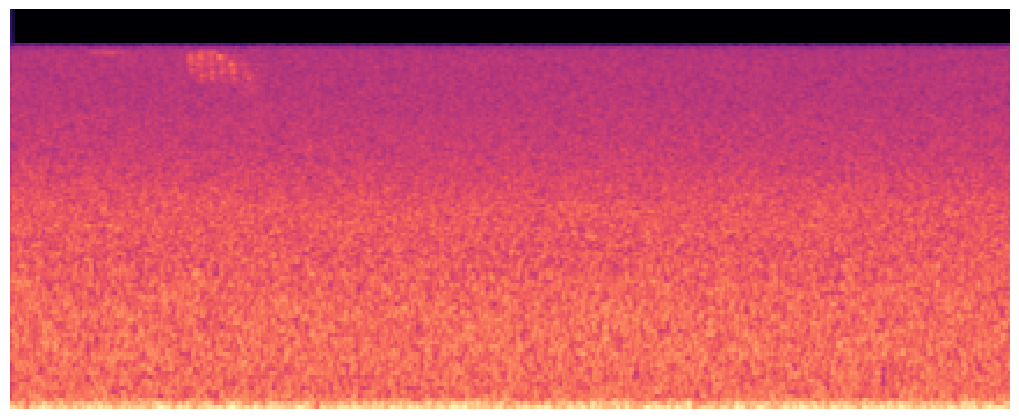

In [7]:

# Zorg dat 'wav_bestanden' en 'data_map' bestaan uit de vorige cellen
if 'wav_bestanden' not in locals() or not wav_bestanden:
    print("Run eerst de vorige cel om 'wav_bestanden' te vullen.")
else:
    # --- 1. Definieer en maak de output map ---
    
    # Weet waar je notebook is. 
    # Path.cwd() is de "Current Working Directory"
    # (Normaal gesproken /home/crabbedfish/Documents/GitHub/DataScienceProjectweek2025/)
    huidige_map = Path.cwd() 
    
    # Maak een nieuwe map genaamd 'spectrograms' in die map
    output_dir = huidige_map / "spectrograms"
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Alle afbeeldingen worden opgeslagen in: {output_dir}")

    # --- Constantes voor het genereren ---
    SAMPLE_RATE = 22050
    N_MELS = 128 # 128 frequentiebanden (hoogte van de afbeelding)

    # --- 2. Loop door ALLE bestanden ---
    
    # tqdm() wikkelt zich om je lijst en toont een voortgangsbalk
    for wav_file in tqdm(wav_bestanden, desc="Spectrograms opslaan"):
        try:
            # --- 3. Genereren (zelfde als voorheen) ---
            y, sr = librosa.load(wav_file, sr=SAMPLE_RATE)
            
            # Sla over als het bestand te kort is (bijv. leeg)
            if len(y) < 512: # Minimaal 1 frame
                print(f"Bestand {wav_file.name} is te kort, wordt overgeslagen.")
                continue

            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
            S_db = librosa.power_to_db(S, ref=np.max)

            # --- 4. Opslaan als 'kale' afbeelding ---
            
            # Maak een nieuwe, lege figuur
            fig = plt.figure(figsize=(10, 4)) # Grootte is niet super belangrijk, we croppen toch
            
            # Teken het spectrogram
            librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
            
            # VERWIJDER alle assen, labels, en witranden
            plt.axis('off')
            plt.tight_layout(pad=0)
            
            # Bepaal de naam van het output-bestand
            # We gebruiken .stem om de extensie (.wav) eraf te halen
            output_filename = output_dir / (wav_file.stem + ".png")
            
            # Sla op (bbox_inches='tight' en pad_inches=0 zijn cruciaal voor 'croppen')
            plt.savefig(output_filename, bbox_inches='tight', pad_inches=0)

            # --- 5. Sluit de figuur (BELANGRIJK!) ---
            # Dit voorkomt dat de plot wordt getoond en bespaart geheugen
            plt.close(fig)

        except Exception as e:
            # Vang eventuele fouten op (bijv. corrupte bestanden)
            print(f"Fout bij verwerken van {wav_file.name}: {e}")

    print("\n✅ Verwerking voltooid!")
    print(f"Alle spectrogrammen zijn opgeslagen in de map 'spectrograms'.")

In [8]:
# Zorgt dat plots direct in het notebook verschijnen
%matplotlib inline

# --- HIER ZIJN JE PATHS INGEVULD ---
# De map waar je alle .txt bestanden staan
DATA_DIR = "/home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data"
# De map waar de .wav bestanden staan
AUDIO_DIR = "/home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data/src_wavs"
# ------------------------------------

# 1. Laad bestandsnamen
# Let op: de separator is een spatie
df_files = pd.read_csv(
    os.path.join(DATA_DIR, "rec_id2filename.txt"), 
    sep=" ", 
    header=None, 
    names=['rec_id', 'filename']
)

# 2. Laad de train/test folds
# Dit bestand heeft geen header
df_folds = pd.read_csv(
    os.path.join(DATA_DIR, "CVfolds_2.txt"), 
    header=None, 
    names=['fold']
)
# Voeg rec_id toe (de index van de rij is de rec_id)
df_folds['rec_id'] = df_folds.index

# 3. Laad de labels
# ---- FIX VOOR DE PARSERERROR ----
# De fout 'Expected 2 fields in line 4, saw 3' ontstaat omdat
# pandas standaard de komma als scheidingsteken (sep) gebruikt.
# Dit bestand heeft echter een wisselend aantal komma's per regel:
# Test-regels hebben 1 komma (bv. "0,?")
# Train-regels hebben er 2 of meer (bv. "14,0,4")
#
# We forceren pandas om de *hele regel* als één veld (string) te lezen
# door een scheidingsteken op te geven dat niet in het bestand voorkomt.
# Een tab ('\t') is hiervoor een veilige keuze.

df_labels_raw = pd.read_csv(
    os.path.join(DATA_DIR, "rec_labels_test_hidden.txt"), 
    header=None, 
    names=['raw_labels'],
    sep='\t' # GEBRUIK TAB ALS SEPARATOR (DIT IS DE FIX)
)
# ---------------------------------


# 4. Verwerk de labels
# Filter de test-data eruit (die hebben een '?')
df_labels = df_labels_raw[~df_labels_raw['raw_labels'].str.contains('\?')].copy()

# Extract het rec_id veilig met een regex (verwijdert ook header- of andere niet-numerieke regels)
df_labels['rec_id'] = df_labels['raw_labels'].str.extract(r'^(\d+)', expand=False)
# Verwijder rijen waar geen rec_id gevonden is (bijv. header "rec_id,[labels]")
df_labels = df_labels[df_labels['rec_id'].notna()].copy()
df_labels['rec_id'] = df_labels['rec_id'].astype(int)

# Sla de labels op als een lijst van strings (bv. ['0', '4'])
def _parse_labels(s):
    parts = s.split(',')
    if len(parts) <= 1:
        return []
    return parts[1:]

df_labels['labels'] = df_labels['raw_labels'].apply(_parse_labels)


# 5. Alles samenvoegen
df_merged = df_files.merge(df_folds, on='rec_id')
df_merged = df_merged.merge(df_labels, on='rec_id')

# [cite_start]6. Selecteer alleen de training data (fold == 0) [cite: 7]
df_train = df_merged[df_merged['fold'] == 0].copy()

# Reset de index voor de zekerheid
df_train = df_train.reset_index(drop=True)

print(f"Totaal {len(df_train)} trainingsbestanden gevonden.")
df_train.head()

Totaal 0 trainingsbestanden gevonden.


,rec_id,filename,fold,raw_labels,labels
